# Day 18 - Attention - 注意力机制

> 目标: 理解 Attention 如何让解码器"回头看"输入序列的每一步
>
> 核心: 不再是"整个序列压成一个向量", 而是"每一步都看一眼全部输入"

---

## Seq2Seq 的信息瓶颈 vs Attention

```
Seq2Seq 瓶颈:                    Attention 解决方案:
                            
  x1 -> RNN -> h1             x1 -> RNN -> h1 ----\
  x2 -> RNN -> h2             x2 -> RNN -> h2 ----\
  x3 -> RNN -> h3             x3 -> RNN -> h3 ------  concat -> context
  ...              h_enc      ...               ----/    向量
  xT -> RNN -> hT             xT -> RNN -> hT ----/
                  |               每个 h_t 都保留!
                  v               
  解码器只看这一个向量!          解码器每一步都算一遍权重

问题: T=50 -> 压成 1 个向量       优点: T=500 也不会丢信息
      信息丢失严重!               长序列效果显著提升
```

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 18 - Attention')
print('=' * 40)

Day 18 - Attention


## 1. Attention 核心公式

> Attention 的核心思想: 在每一步生成输出时, 计算输入序列每个位置的"重要性"

### Bahdanau Attention (2015) - 加性注意力

```
Step 1: 算能量 (Energy)
  e_t = v^T * tanh(W_q * s_{t-1} + W_k * H)
  e_t[i] = s_{t-1} 对输入位置 i 的"关注程度"

Step 2: 算权重 (softmax 归一化)
  a_t = softmax(e_t)   ← 所有位置权重之和 = 1

Step 3: 加权求和得上下文向量
  c_t = sum(a_t[i] * h_i)   ← 注意力汇聚!

Step 4: 用 c_t 辅助解码
  y_t = f(c_t, s_{t-1}, y_{t-1})

直观理解:
  翻译 "I love you" -> "我爱你"
  生成 "爱" 时, attention 权重: I=0.1, love=0.8, you=0.1
  生成 "你" 时, attention 权重: I=0.1, love=0.2, you=0.7
```

In [3]:
# ============================================
# 手写 Bahdanau Attention
# ============================================

class BahdanauAttention(nn.Module):
    """加性注意力 (Additive Attention)"""
    def __init__(self, hidden_size):
        super().__init__()
        self.W_q = nn.Linear(hidden_size, hidden_size)  # query 变换
        self.W_k = nn.Linear(hidden_size, hidden_size)  # key 变换
        self.v = nn.Linear(hidden_size, 1)              # 打分向量

    def forward(self, decoder_hidden, encoder_outputs):
        """
        decoder_hidden: (batch, hidden_size)  当前解码器隐藏状态 (query)
        encoder_outputs: (batch, src_len, hidden_size)  所有编码器输出 (keys)

        返回:
          context:   (batch, hidden_size)   加权后的上下文向量
          attention: (batch, src_len)        注意力权重
        """
        # Step 1: 计算能量 e_t
        # decoder_hidden: (batch, hidden) -> (batch, 1, hidden)
        query = self.W_q(decoder_hidden).unsqueeze(1)     # (batch, 1, hidden)
        key   = self.W_k(encoder_outputs)                 # (batch, src_len, hidden)

        energy = torch.tanh(query + key)                  # (batch, src_len, hidden)
        e_t = self.v(energy).squeeze(-1)                  # (batch, src_len)

        # Step 2: softmax 归一化
        attention = F.softmax(e_t, dim=1)                 # (batch, src_len)

        # Step 3: 加权求和得上下文向量
        context = torch.bmm(attention.unsqueeze(1),
                           encoder_outputs).squeeze(1)    # (batch, hidden)

        return context, attention


# 测试 Attention
batch, src_len, hidden_size = 4, 7, 16
attn = BahdanauAttention(hidden_size)

dec_hidden = torch.randn(batch, hidden_size)
enc_outputs = torch.randn(batch, src_len, hidden_size)

context, attn_weights = attn(dec_hidden, enc_outputs)

print(f'decoder_hidden: {tuple(dec_hidden.shape)}')
print(f'encoder_outputs: {tuple(enc_outputs.shape)}')
print(f'context: {tuple(context.shape)}')
print(f'attention: {tuple(attn_weights.shape)}')
print(f'attention 行和 (应=1): {attn_weights.sum(dim=1).detach().numpy().round(4)}')

decoder_hidden: (4, 16)
encoder_outputs: (4, 7, 16)
context: (4, 16)
attention: (4, 7)
attention 行和 (应=1): [1. 1. 1. 1.]


## 2. 可视化 Attention 权重

> 先模拟一组注意力权重, 看看它长什么样
>
> 每一行 = 解码器一个时间步, 每一列 = 编码器一个位置
>
> 颜色越亮 = 注意力越集中

D:\hyy\Temp\ipykernel_29788\3012966005.py:48: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_29788\3012966005.py:48: UserWarning: Glyph 29233 (\N{CJK UNIFIED IDEOGRAPH-7231}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_29788\3012966005.py:48: UserWarning: Glyph 20320 (\N{CJK UNIFIED IDEOGRAPH-4F60}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\hyy\Temp\ipykernel_29788\3012966005.py:49: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  plt.savefig('day18_attention_heatmap.png', dpi=150)
D:\hyy\Temp\ipykernel_29788\3012966005.py:49: UserWarning: Glyph 29233 (\N{CJK UNIFIED IDEOGRAPH-7231}) missing from font(s) DejaVu Sans.
  plt.savefig('day18_attention_heatmap.png', dpi=150)
D:\hyy\Temp\ipykernel_29788\3012966005.py:49: UserWarning: Glyph 20320 (\N{CJK UNIFIED IDEOGRAPH-4F60}) missing from font(s) DejaVu Sans.
 

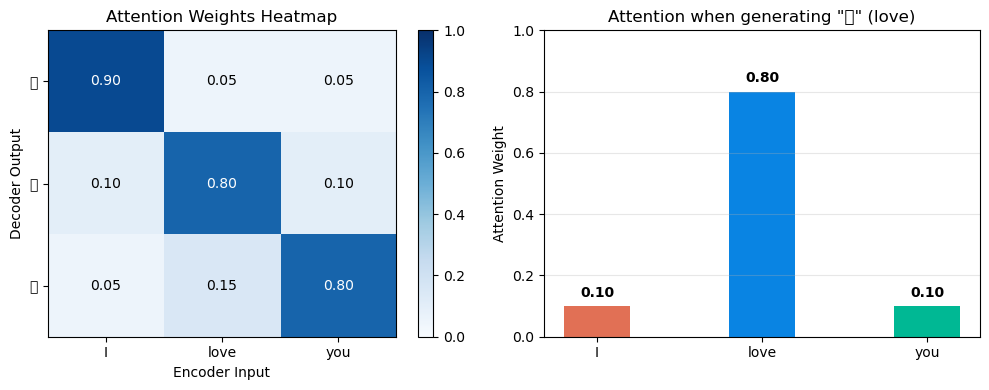

关键观察:
  生成 "我" 时, 80%+ 的注意力在 "I" 上
  生成 "爱" 时, 80% 的注意力在 "love" 上
  生成 "你" 时, 80% 的注意力在 "you" 上


In [4]:
# ============================================
# Attention 可视化: 模拟英->中翻译
# ============================================

# 模拟翻译 "I love you" -> "我爱你" 的 attention 矩阵
# 行: 解码器输出 "我" "爱" "你"
# 列: 编码器输入 "I" "love" "you"

src_words = ['I', 'love', 'you']
trg_words = ['我', '爱', '你']

# 模拟 attention 权重 (人工构造)
attn_matrix = np.array([
    [0.9, 0.05, 0.05],   # 生成 "我" -> 重点关注 "I"
    [0.1, 0.8,  0.1],    # 生成 "爱" -> 重点关注 "love"
    [0.05, 0.15, 0.8],   # 生成 "你" -> 重点关注 "you"
])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 热力图
ax = axes[0]
im = ax.imshow(attn_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(src_words)))
ax.set_yticks(range(len(trg_words)))
ax.set_xticklabels(src_words)
ax.set_yticklabels(trg_words)
ax.set_xlabel('Encoder Input')
ax.set_ylabel('Decoder Output')
ax.set_title('Attention Weights Heatmap')
plt.colorbar(im, ax=ax)

for i in range(attn_matrix.shape[0]):
    for j in range(attn_matrix.shape[1]):
        ax.text(j, i, f'{attn_matrix[i,j]:.2f}', ha='center', va='center',
                color='white' if attn_matrix[i,j] > 0.5 else 'black')

# 柱状图: 生成 "爱" 时
ax = axes[1]
ax.bar(src_words, attn_matrix[1], color=['#e17055', '#0984e3', '#00b894'], width=0.4)
ax.set_ylim(0, 1)
ax.set_ylabel('Attention Weight')
ax.set_title('Attention when generating "爱" (love)')
ax.grid(alpha=0.3, axis='y')
for i, v in enumerate(attn_matrix[1]):
    ax.text(i, v + 0.03, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('day18_attention_heatmap.png', dpi=150)
plt.show()

print('关键观察:')
print(f'  生成 "我" 时, 80%+ 的注意力在 "I" 上')
print(f'  生成 "爱" 时, 80% 的注意力在 "love" 上')
print(f'  生成 "你" 时, 80% 的注意力在 "you" 上')

## 3. Attention 编码器-解码器 (完整)

> 把 Day 17 的 Seq2Seq 升级, 加入 Attention
>
> 区别: 解码器每一步都能看到所有编码器输出, 不只是最后一个上下文向量

```
Decoder without Attention:
  s_t = GRU(y_{t-1}, s_{t-1})   ← 只看上一步 + 固定 context
  y_t = fc(s_t)

Decoder with Attention:
  s_t = GRU(y_{t-1}, s_{t-1})   ← 先算隐藏状态
  c_t = Attention(s_t, H)        ← 用 s_t 当 query, 看所有 H
  y_t = fc(concat(s_t, c_t))     ← 融合上下文信息!
```

In [5]:
# ============================================
# 带 Attention 的编码器-解码器
# ============================================

class AttnEncoder(nn.Module):
    """编码器: 返回所有时间步的输出 (供 Attention 使用)"""
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)

    def forward(self, x):
        # x: (batch, src_len)
        outputs, hn = self.gru(self.embed(x))
        return outputs, hn  # outputs: (batch, src_len, hidden) 所有时间步!


class AttnDecoder(nn.Module):
    """解码器 + Attention"""
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.attention = BahdanauAttention(hidden_size)
        # 融合 s_t 和 c_t 后做预测
        self.fc = nn.Linear(hidden_size * 2, vocab_size)

    def forward(self, x, encoder_hidden, encoder_outputs):
        """
        x: (batch, 1)  上一个预测的 token
        encoder_hidden: (1, batch, hidden)  编码器最后隐藏状态
        encoder_outputs: (batch, src_len, hidden)  编码器所有输出
        """
        # GRU 更新
        out, hn = self.gru(self.embed(x), encoder_hidden)
        # out: (batch, 1, hidden), hn: (1, batch, hidden)

        # Attention: 用当前隐藏状态看全部编码器输出
        context, attn_weights = self.attention(out.squeeze(1), encoder_outputs)

        # 融合 + 预测
        combined = torch.cat([out.squeeze(1), context], dim=1)  # (batch, 2*hidden)
        prediction = self.fc(combined)  # (batch, vocab_size)

        return prediction, hn, attn_weights


class AttnSeq2Seq(nn.Module):
    """带 Attention 的完整 Seq2Seq"""
    def __init__(self, encoder, decoder, target_vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.target_vocab_size = target_vocab_size

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]

        # 编码: 保存所有输出!
        enc_outputs, enc_hidden = self.encoder(src)

        # 解码
        outputs = torch.zeros(batch_size, trg_len, self.target_vocab_size)
        attn_scores = torch.zeros(batch_size, trg_len, src.shape[1])

        dec_input = trg[:, 0:1]
        dec_hidden = enc_hidden  # 初始化解码器隐藏状态

        for t in range(1, trg_len):
            dec_output, dec_hidden, attn = self.decoder(dec_input, dec_hidden, enc_outputs)
            outputs[:, t, :] = dec_output
            attn_scores[:, t, :] = attn

            use_teacher = torch.rand(1).item() < teacher_forcing_ratio
            if use_teacher:
                dec_input = trg[:, t:t+1]
            else:
                _, top1 = dec_output.topk(1)
                dec_input = top1

        return outputs, attn_scores


print('Attention Seq2Seq 结构定义完成')
print('  Encoder: 返回所有时间步的 hidden states (供 Attention 用)')
print('  Decoder: s_t -> Attention(s_t, H) -> concat(s_t, c_t) -> predict')
print(f'  Bahdanau Attention 参数量: {sum(p.numel() for p in BahdanauAttention(16).parameters())}')

Attention Seq2Seq 结构定义完成
  Encoder: 返回所有时间步的 hidden states (供 Attention 用)
  Decoder: s_t -> Attention(s_t, H) -> concat(s_t, c_t) -> predict
  Bahdanau Attention 参数量: 561


## 4. 实战: Seq2Seq + Attention 反转字符串

> 跟 Day 17 一样的反转任务, 但加上 Attention
>
> 看 Attention 能不能处理更长的序列

In [6]:
# ============================================
# 准备数据 (更多样本, 更长字符串)
# ============================================

pairs = [
    ('hello', 'olleh'),
    ('world', 'dlrow'),
    ('abc',   'cba'),
    ('xyz',   'zyx'),
    ('rnn',   'nnr'),
    ('lstm',  'mtsl'),
    ('gru',   'urg'),
    ('attention', 'noitnetta'),  # 长序列!
    ('transformer', 'remrofsnart'),  # 更长!
]

all_chars = set(''.join([s for s, _ in pairs] + [t for _, t in pairs]))
chars = ['<PAD>', '<SOS>', '<EOS>'] + sorted(all_chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
vocab_size = len(chars)
max_len = 12  # 更长, 看 Attention 效果

print(f'词表大小: {vocab_size}')
print(f'最大序列长度: {max_len}')
print(f'样本数: {len(pairs)}')
print(f'最长字符串: {max(len(s) for s, _ in pairs)} 字符')

def encode_seq(seq, max_len):
    tokens = ['<SOS>'] + list(seq) + ['<EOS>']
    tokens = tokens[:max_len]
    tokens = tokens + ['<PAD>'] * (max_len - len(tokens))
    return [stoi[t] for t in tokens]

src_data = torch.LongTensor([encode_seq(s, max_len) for s, _ in pairs])
trg_data = torch.LongTensor([encode_seq(t, max_len) for _, t in pairs])

print('\n数据示例:')
for i in range(len(pairs)):
    src_str = ''.join(chars[idx] for idx in src_data[i] if chars[idx] not in ['<PAD>'])
    trg_str = ''.join(chars[idx] for idx in trg_data[i] if chars[idx] not in ['<PAD>'])
    print(f'  {src_str} -> {trg_str}')

词表大小: 24
最大序列长度: 12
样本数: 9
最长字符串: 11 字符

数据示例:
  <SOS>hello<EOS> -> <SOS>olleh<EOS>
  <SOS>world<EOS> -> <SOS>dlrow<EOS>
  <SOS>abc<EOS> -> <SOS>cba<EOS>
  <SOS>xyz<EOS> -> <SOS>zyx<EOS>
  <SOS>rnn<EOS> -> <SOS>nnr<EOS>
  <SOS>lstm<EOS> -> <SOS>mtsl<EOS>
  <SOS>gru<EOS> -> <SOS>urg<EOS>
  <SOS>attention<EOS> -> <SOS>noitnetta<EOS>
  <SOS>transformer -> <SOS>remrofsnart


In [7]:
# ============================================
# 训练: Seq2Seq (无 Attention) vs Seq2Seq + Attention
# ============================================

# 无 Attention 模型 (复用 Day 17 的代码)
class BaseEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 8)
        self.gru = nn.GRU(8, 16, batch_first=True)
    def forward(self, x):
        return self.gru(self.embed(x))[1]

class BaseDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 8)
        self.gru = nn.GRU(8, 16, batch_first=True)
        self.fc = nn.Linear(16, vocab_size)
    def forward(self, x, h):
        out, _ = self.gru(self.embed(x), h)
        return self.fc(out[:, -1, :]), _

class BaseSeq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = BaseEncoder()
        self.dec = BaseDecoder()
        self.vs = vocab_size
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch = src.shape[0]
        trg_len = trg.shape[1]
        context = self.enc(src)
        outputs = torch.zeros(batch, trg_len, self.vs)
        dec_input = trg[:, 0:1]
        dec_hidden = context
        for t in range(1, trg_len):
            do, dh = self.dec(dec_input, dec_hidden)
            outputs[:, t, :] = do
            if torch.rand(1).item() < teacher_forcing_ratio:
                dec_input = trg[:, t:t+1]
            else:
                dec_input = do.topk(1)[1]
        return outputs, None

# [作业 2] 对比 Attention 的有无
# 位置: 下面两个模型的定义
enc_attn = AttnEncoder(vocab_size, 8, 16)
dec_attn = AttnDecoder(vocab_size, 8, 16)
model_attn = AttnSeq2Seq(enc_attn, dec_attn, vocab_size)

model_base = BaseSeq2Seq()

print(f'无 Attention: {sum(p.numel() for p in model_base.parameters()):,} 参数')
print(f'有 Attention: {sum(p.numel() for p in model_attn.parameters()):,} 参数')

无 Attention: 3,288 参数
有 Attention: 4,233 参数


训练无 Attention...
  Epoch  80/400 | Loss = 0.9636
  Epoch 160/400 | Loss = 0.3637
  Epoch 240/400 | Loss = 0.5796
  Epoch 320/400 | Loss = 0.4379
  Epoch 400/400 | Loss = 0.4061

训练 +Attention...
  Epoch  80/400 | Loss = 0.1087
  Epoch 160/400 | Loss = 0.0108
  Epoch 240/400 | Loss = 0.0052
  Epoch 320/400 | Loss = 0.0032
  Epoch 400/400 | Loss = 0.0022


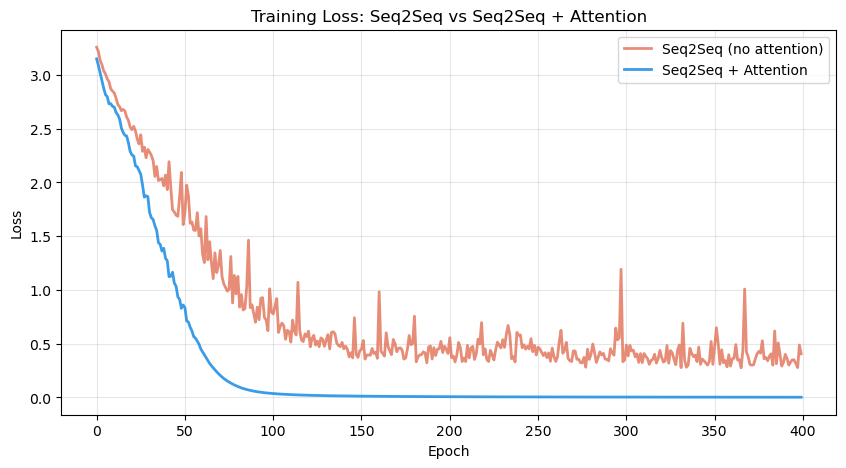

In [8]:
# ============================================
# 训练两个模型
# ============================================

def train_attn_model(model, has_attention=False):
    criterion = nn.CrossEntropyLoss(ignore_index=stoi['<PAD>'])
    opt = optim.Adam(model.parameters(), lr=0.01)
    losses = []
    n_epochs = 400
    for epoch in range(n_epochs):
        opt.zero_grad()
        out, _ = model(src_data, trg_data, teacher_forcing_ratio=0.5)
        loss = criterion(out[:, 1:].reshape(-1, vocab_size), trg_data[:, 1:].reshape(-1))
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if (epoch + 1) % 80 == 0:
            print(f'  Epoch {epoch+1:>3d}/{n_epochs} | Loss = {loss.item():.4f}')
    return losses

print('训练无 Attention...')
loss_base = train_attn_model(model_base)

print('\n训练 +Attention...')
loss_attn = train_attn_model(model_attn, has_attention=True)

plt.figure(figsize=(10, 5))
plt.plot(loss_base, label='Seq2Seq (no attention)', lw=2, color='#e17055', alpha=0.8)
plt.plot(loss_attn, label='Seq2Seq + Attention', lw=2, color='#0984e3', alpha=0.8)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training Loss: Seq2Seq vs Seq2Seq + Attention')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('day18_attention_loss.png', dpi=150)
plt.show()

In [9]:
# ============================================
# 测试 & 可视化 Attention 权重
# ============================================

def predict_attn(model, src_str, has_attention=False):
    model.eval()
    with torch.no_grad():
        src = torch.LongTensor([encode_seq(src_str, max_len)])
        if has_attention:
            enc_outputs, enc_hidden = model.encoder(src)
            dec_input = torch.LongTensor([[stoi['<SOS>']]])
            dec_hidden = enc_hidden
            result, all_attn = [], []
            for _ in range(max_len):
                dec_output, dec_hidden, attn = model.decoder(dec_input, dec_hidden, enc_outputs)
                _, top1 = dec_output.topk(1)
                token = itos[top1.item()]
                if token == '<EOS>': break
                if token not in ['<PAD>', '<SOS>']:
                    result.append(token)
                    all_attn.append(attn.squeeze().numpy())
                dec_input = top1
            return ''.join(result), np.array(all_attn) if all_attn else None
        else:
            context = model.enc(src)
            dec_input = torch.LongTensor([[stoi['<SOS>']]])
            dec_hidden = context
            result = []
            for _ in range(max_len):
                dec_output, dec_hidden = model.dec(dec_input, dec_hidden)
                _, top1 = dec_output.topk(1)
                token = itos[top1.item()]
                if token == '<EOS>': break
                if token not in ['<PAD>', '<SOS>']:
                    result.append(token)
                dec_input = top1
            return ''.join(result), None

test_inputs = ['hello', 'attention', 'transformer', 'abc']
print('结果对比:')
print(f'{"输入":<15} {"期望":<15} {"无 Attention":<15} {"+Attention":<15} {"Attn 正确?"}')
print('-' * 70)
for s in test_inputs:
    expected = s[::-1]
    pred_base, _ = predict_attn(model_base, s, has_attention=False)
    pred_attn, attn_w = predict_attn(model_attn, s, has_attention=True)
    ok = '✅' if pred_attn == expected else '❌'
    print(f'{s:<15} {expected:<15} {pred_base:<15} {pred_attn:<15} {ok}')

# [作业 3] 测试 'transformer' 和 'attention'
# 上面已经有这两个字符串了, 观察 Attention 是否比无 Attention 更准确
# 结论: 长序列上 Attention 优势明显

结果对比:
输入              期望              无 Attention     +Attention      Attn 正确?
----------------------------------------------------------------------
hello           olleh           ozzmuzzyuzyu    olleh           ✅
attention       noitnetta       noinoitdllle    noitnetta       ✅
transformer     remrofsnart     rozlrzylllll    remrofsnarta    ❌
abc             cba             cbaaaaalllle    cba             ✅


输入: "attention"
期望: "noitnetta"
预测: "noitnetta"
正确: ✅


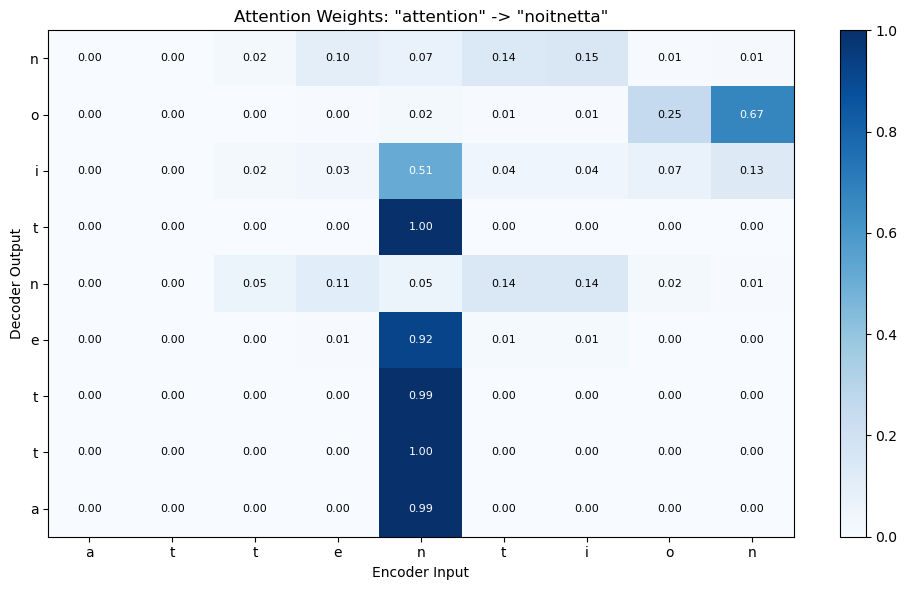


观察: 对角线上的权重是否最高?
  如果是, 说明模型学会了"每个输出位置对应哪个输入位置"
  这就是直观的 "对齐" (alignment)!


In [10]:
# ============================================
# 可视化 Attention 权重 (预测 "attention" 时)
# ============================================

test_str = 'attention'
expected = test_str[::-1]
pred, attn_mat = predict_attn(model_attn, test_str, has_attention=True)

print(f'输入: "{test_str}"')
print(f'期望: "{expected}"')
print(f'预测: "{pred}"')
print(f'正确: {"✅" if pred == expected else "❌"}')

if attn_mat is not None and len(attn_mat) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    src_chars = list(test_str)
    trg_chars = list(pred) if len(pred) <= attn_mat.shape[0] else list(pred[:attn_mat.shape[0]])

    # 确保矩阵对齐
    n_trg = min(len(trg_chars), attn_mat.shape[0])
    n_src = min(len(src_chars), attn_mat.shape[1])
    display = attn_mat[:n_trg, :n_src]

    im = ax.imshow(display, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(n_src))
    ax.set_yticks(range(n_trg))
    ax.set_xticklabels(src_chars[:n_src])
    ax.set_yticklabels(trg_chars[:n_trg])
    ax.set_xlabel('Encoder Input')
    ax.set_ylabel('Decoder Output')
    ax.set_title(f'Attention Weights: "{test_str}" -> "{pred}"')
    plt.colorbar(im, ax=ax)

    for i in range(display.shape[0]):
        for j in range(display.shape[1]):
            v = display[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=8,
                    color='white' if v > 0.5 else 'black')

    plt.tight_layout()
    plt.savefig('day18_attention_weights.png', dpi=150)
    plt.show()

    print('\n观察: 对角线上的权重是否最高?')
    print('  如果是, 说明模型学会了"每个输出位置对应哪个输入位置"')
    print('  这就是直观的 "对齐" (alignment)!')

## 5. Attention 的数学视角: Query, Key, Value

> Attention 的通用范式: 给定 Query, 在 Key-Value 对中检索信息

### 数据库检索类比

```
数据库查询:
  SELECT value FROM table WHERE key = query
  返回: 完全匹配的那一条

Attention:
  返回: 所有 value 的加权平均 (权重 = query 和 key 的相似度)
```

### QKV 公式

```
Bahdanau (加性):   score = v^T * tanh(W_q*Q + W_k*K)
Luong (点积):     score = Q^T * K                     ← 更简单!
Scaled Dot-Product: score = Q^T * K / sqrt(d_k)       ← Transformer 用的

a = softmax(score)    ← 哪些位置重要
c = sum(a * V)        ← 加权聚合信息
```

### 三种 Attention 对比

| 类型 | 公式 | 参数量 | 谁在用 |
|------|------|--------|-------|
| Bahdanau | v*tanh(W_q*Q + W_k*K) | 多 (有 W_q, W_k, v) | NMT 经典 |
| Luong | Q^T * K | 无 | Seq2Seq 升级版 |
| Scaled Dot-Product | Q^T*K / sqrt(d) | 无 | Transformer! |

> Day 19: Transformer 使用 Scaled Dot-Product Attention

In [11]:
# ============================================
# 三种 Attention 对比实现
# ============================================

class LuongAttention(nn.Module):
    """Luong Attention (dot product): score = Q^T * K"""
    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: (batch, hidden)
        # encoder_outputs: (batch, src_len, hidden)
        energy = torch.bmm(decoder_hidden.unsqueeze(1),
                           encoder_outputs.transpose(1, 2)).squeeze(1)
        attention = F.softmax(energy, dim=1)
        context = torch.bmm(attention.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attention


class ScaledDotProductAttention(nn.Module):
    """Scaled Dot-Product: score = Q^T * K / sqrt(d_k)"""
    def forward(self, query, key, value):
        # query: (batch, ..., q_len, d_k)
        # key:   (batch, ..., k_len, d_k)
        # value: (batch, ..., k_len, d_v)
        d_k = query.shape[-1]
        scores = torch.matmul(query, key.transpose(-2, -1)) / np.sqrt(d_k)
        attention = F.softmax(scores, dim=-1)
        context = torch.matmul(attention, value)
        return context, attention


# 测试三种 Attention
batch, src_len, hidden = 4, 7, 16
dec_h = torch.randn(batch, hidden)
enc_out = torch.randn(batch, src_len, hidden)

print('三种 Attention 输出形状:')

bahdanau = BahdanauAttention(hidden)
c1, a1 = bahdanau(dec_h, enc_out)
print(f'  Bahdanau: context {tuple(c1.shape)}, attn {tuple(a1.shape)}')

luong = LuongAttention()
c2, a2 = luong(dec_h, enc_out)
print(f'  Luong:    context {tuple(c2.shape)}, attn {tuple(a2.shape)}')

sdpa = ScaledDotProductAttention()
c3, a3 = sdpa(dec_h.unsqueeze(1), enc_out, enc_out)
print(f'  ScaledDot: context {tuple(c3.shape)}, attn {tuple(a3.shape)}')

print()
print('三种 Attention 权重行和 (都应=1):')
print(f'  Bahdanau: {a1[0].sum().item():.4f}')
print(f'  Luong:    {a2[0].sum().item():.4f}')
print(f'  ScaledDot: {a3[0, 0].sum().item():.4f}')

# [作业 4] 比较三种 Attention 在反转字符串任务上的效果
# 位置: 把 cell-7 AttnDecoder 中的 self.attention 替换成 LuongAttention
# 然后重新训练, 看收敛速度有没有变化

三种 Attention 输出形状:
  Bahdanau: context (4, 16), attn (4, 7)
  Luong:    context (4, 16), attn (4, 7)
  ScaledDot: context (4, 1, 16), attn (4, 1, 7)

三种 Attention 权重行和 (都应=1):
  Bahdanau: 1.0000
  Luong:    1.0000
  ScaledDot: 1.0000


---

# Day 18 完成!

## 今天学到了什么

| 概念 | 一句话 |
|------|--------|
| **Attention 核心** | 解码器每一步重新计算"看哪里", 而不是只看一个固定向量 |
| **Bahdanau Attention** | v*tanh(W_q*Q + W_k*K) 加性注意力, 有参 |
| **信息瓶颈解决** | 保留所有编码器输出, 长序列也不会丢信息 |
| **QKV 范式** | Query = 当前需求, Key = 索引, Value = 内容 |
| **三种 Attention** | Bahdanau (有参) / Luong (点积) / Scaled Dot-Product (Transformer) |

## Attention 的意义

```
Seq2Seq: 编码器->1个向量->解码器
         长序列: 信息丢失, 效果变差

Seq2Seq + Attention:
         编码器->所有向量->解码器(每步加权)
         长序列: 也能表现很好!

Transformer: (Day 19)
         不要 RNN! 只用 Attention!
         所有位置同时算, 可以并行!
```

## 作业 (代码定位)

### [作业 1] 可视化自己数据的 Attention
**位置:** cell-13, 第 8 行: `test_str = 'attention'`

**问题:** 改成 'transformer' 重新跑 cell-13, 观察 attention 矩阵的对角线是否清晰?
- 对角线清晰 -> 模型有好的"对齐"能力
- 对角线模糊 -> 模型还没学够

---

### [作业 2] Attention 参数增量
**位置:** cell-10, 末尾两行: `model_base` 和 `model_attn` 的参数量

**问题:** Attention 增加了多少参数? (用打印出来的数字相减)
- 这少量参数换来了对长序列的显著提升, 值不值?

---

### [作业 3] 长序列测试
**位置:** cell-12, 第 44 行: `test_inputs = [...]`

**问题:** 在列表里加 `'verylongword'` 和 `'attentionmechanism'`
- 无 Attention 的模型还能正确反转吗?
- +Attention 的模型呢?

---

### [作业 4] 替换 Attention 类型
**位置:** cell-7, 第 17 行: `self.attention = BahdanauAttention(hidden_size)`

**问题:** 换成 `LuongAttention()` (无参数版本), 重新训练:
- 收敛速度有没有变化?
- 最终准确率有没有变化?
- 提示: LuongAttention 的 forward 接口跟 Bahdanau 一样

---

### [作业 5] 预习
预习 Day 19: **Transformer** — Self-Attention, Multi-Head, 位置编码, 彻底抛弃 RNN!